## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import math

In [2]:
df = pd.read_csv("diet_calorie_intake.csv")

In [3]:
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [4]:
df = df.drop(
    columns=[
        "Person_ID",
        "Daily_Calorie_Consumed",
        "Protein_Intake_g",
        "Carbohydrate_Intake_g",
        "Fat_Intake_g",
        "Water_Intake_Liters",
        "Health_Status"
    ]
)

In [5]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Diet_Type
0,50,Male,176.4,74.8,24.0,Very Active,2852,Keto
1,18,Female,167.6,75.5,26.9,Sedentary,1904,Vegan
2,68,Female,161.9,87.2,33.3,Lightly Active,2009,High Protein
3,22,Female,169.3,66.9,23.3,Moderately Active,2318,Balanced
4,30,Male,179.1,75.3,23.5,Sedentary,2144,Balanced


## Data Processing

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(
    df,
    columns=["Activity_Level", "Diet_Type"],
    drop_first=True,
    dtype=int
)

In [7]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Activity_Level_Lightly Active,Activity_Level_Moderately Active,Activity_Level_Sedentary,Activity_Level_Very Active,Diet_Type_High Protein,Diet_Type_Keto,Diet_Type_Mediterranean,Diet_Type_Vegan,Diet_Type_Vegetarian
0,50,1,176.4,74.8,24.0,2852,0,0,0,1,0,1,0,0,0
1,18,0,167.6,75.5,26.9,1904,0,0,1,0,0,0,0,1,0
2,68,0,161.9,87.2,33.3,2009,1,0,0,0,1,0,0,0,0
3,22,0,169.3,66.9,23.3,2318,0,1,0,0,0,0,0,0,0
4,30,1,179.1,75.3,23.5,2144,0,0,1,0,0,0,0,0,0


## Creating testing and training data

In [8]:
X = df.drop(["Daily_Calorie_Requirement"], axis=1)
y = df["Daily_Calorie_Requirement"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Scaling data

In [10]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Convert data to tensor 

In [11]:
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [12]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

## Create train, test tensor datasets and train, test loaders

In [13]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Build ANN

In [15]:
print(X_train.shape[1])

14


In [16]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 64), #first layer
            nn.ReLU(),

            nn.Linear(64, 32), #second layer
            nn.ReLU(),

            nn.Linear(32, 1)  #final layer
        )

    def forward(self, x):
        return self.model(x)

In [17]:
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train model and save the best epoch weights

In [18]:
epochs = 100

best_rmse = float("inf")

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    rmse = math.sqrt(epoch_loss)

    # Save model if RMSE improves
    if rmse < best_rmse:
        best_rmse = rmse

        torch.save(
            model.state_dict(),
            "model.pth"
        )

        print(f"Best model saved! RMSE: {rmse:.2f}")

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.2f}, RMSE: {rmse:.2f}")

Best model saved! RMSE: 2324.53
Epoch [1/100], Loss: 5403454.85, RMSE: 2324.53
Best model saved! RMSE: 2145.68
Epoch [2/100], Loss: 4603961.92, RMSE: 2145.68
Best model saved! RMSE: 1551.27
Epoch [3/100], Loss: 2406429.18, RMSE: 1551.27
Best model saved! RMSE: 760.58
Epoch [4/100], Loss: 578480.16, RMSE: 760.58
Best model saved! RMSE: 391.05
Epoch [5/100], Loss: 152918.97, RMSE: 391.05
Best model saved! RMSE: 310.11
Epoch [6/100], Loss: 96169.06, RMSE: 310.11
Best model saved! RMSE: 270.84
Epoch [7/100], Loss: 73356.01, RMSE: 270.84
Best model saved! RMSE: 239.24
Epoch [8/100], Loss: 57237.04, RMSE: 239.24
Best model saved! RMSE: 211.64
Epoch [9/100], Loss: 44789.40, RMSE: 211.64
Best model saved! RMSE: 187.28
Epoch [10/100], Loss: 35072.74, RMSE: 187.28
Best model saved! RMSE: 166.17
Epoch [11/100], Loss: 27611.48, RMSE: 166.17
Best model saved! RMSE: 148.00
Epoch [12/100], Loss: 21903.77, RMSE: 148.00
Best model saved! RMSE: 132.57
Epoch [13/100], Loss: 17575.97, RMSE: 132.57
Best mo

## Load best model and Evaluate

In [19]:
model = ANN()

model.load_state_dict(
    torch.load("model.pth")
)

<All keys matched successfully>

In [20]:
model.eval()

test_loss = 0

actual = []
predicted = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)

        actual.append(yb)
        predicted.append(outputs)
        
        loss = criterion(outputs, yb)
        test_loss += loss.item()

test_loss = test_loss / len(test_loader)
rmse = math.sqrt(test_loss)

actual = torch.cat(actual, dim=0).cpu().numpy()
predicted = torch.cat(predicted, dim=0).cpu().numpy()

print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 10.27


## Actual v/s Prediction

In [21]:
results = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predicted.flatten()
})

print(results.head())

   Actual    Predicted
0  2587.0  2584.075684
1  2707.0  2707.367920
2  2233.0  2196.690918
3  1740.0  1749.159424
4  2236.0  2236.696533


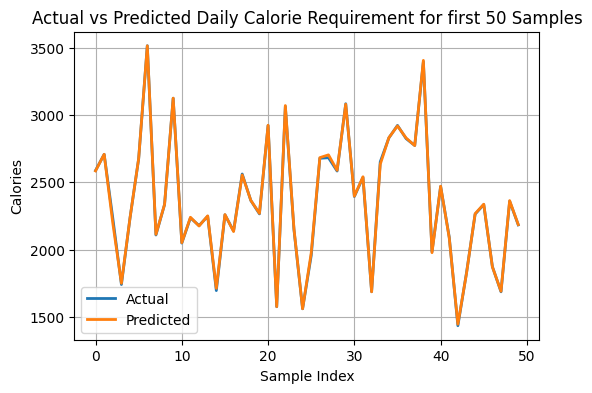

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(results["Actual"][:50], linewidth=2, label="Actual")
plt.plot(results["Predicted"][:50], linewidth=2, label="Predicted")

plt.title("Actual vs Predicted Daily Calorie Requirement for first 50 Samples")
plt.xlabel("Sample Index")
plt.ylabel("Calories")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
from sklearn.metrics import r2_score

r2 = r2_score(results["Actual"], results["Predicted"])
error = abs((results["Actual"] - results["Predicted"])/ results["Actual"]).mean()
accuracy = (1 - error) * 100

print("R² :", r2)
print("Accuracy :", accuracy)

R² : 0.9994967579841614
Accuracy : 99.730606
